In [13]:
import tensorflow as tf
from tensorflow.keras import models,layers
from tensorflow.keras.layers import Dense,Conv2D,Dropout,BatchNormalization
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import os

In [15]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/gaura/Downloads/archive/PlantVillage",
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True
)

Found 2152 files belonging to 3 classes.


In [17]:
class_Names=dataset.class_names

In [19]:
print(class_Names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [21]:
len(dataset)

68

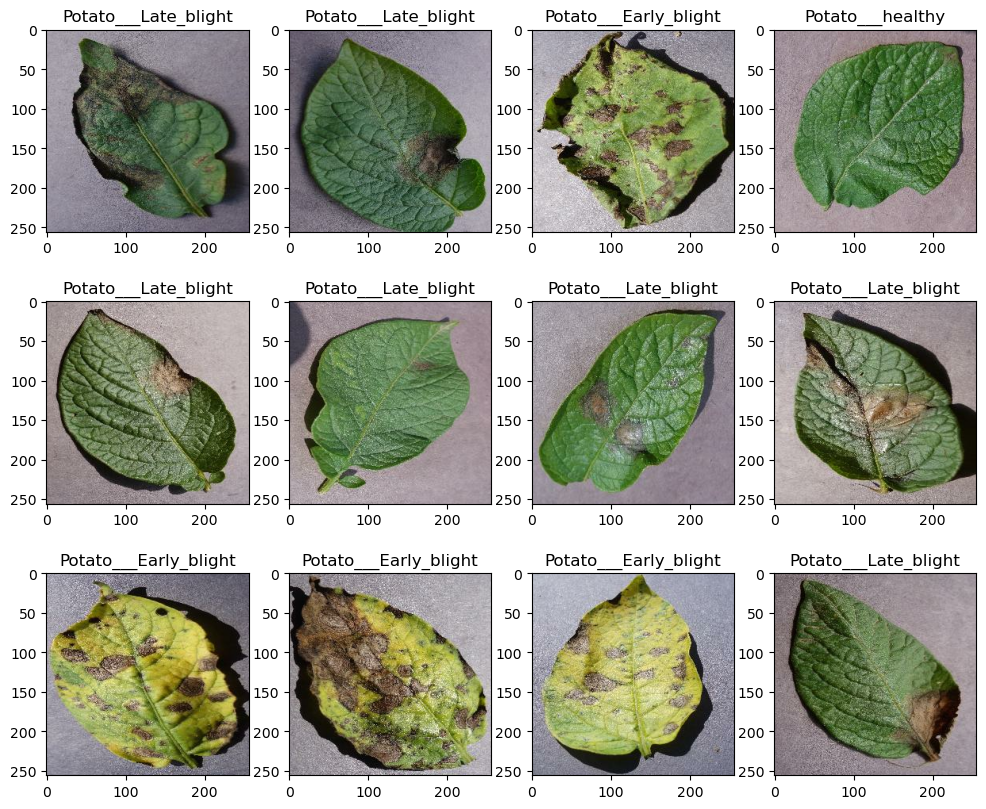

In [23]:
plt.figure(figsize=(12,10))
for image,label in dataset.take(1):
   for i in range(12):
       plt.subplot(3,4,i+1)
       plt.imshow(image[i].numpy().astype(int))
       plt.title(class_Names[label[i]])

train ser=>0.8
test set=>0.1
val set=>0.1

In [26]:
train_ds=dataset.take(54)
test_ds=dataset.skip(54)

val_ds=test_ds.take(6)
test_ds=test_ds.skip(6)

Now we will use cache so that the gpu and cpu can be utilised properly without being ideal when the other is working

In [29]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

as the image is rgb it has 3 layers and each value range from 0 to 255 so we need to rescale it by dividing by 255
and we also need to reshape the image in order to make all the images of same size

In [32]:
resize_rescale=tf.keras.Sequential([
    layers.Resizing(256,256),
    layers.Rescaling(1.0/255)
])

Now we need data Augumnetation so that overfitting can be reduced 
and the model can be robust


In [35]:
data_augumentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

Now we make the CNN model 
convlayer->activation->poolinglayer->flatten->Dense(ANN)

this is a multiclass classification problem so we need softmax at the ouput part 
loss function should be 

In [38]:
model = models.Sequential([
    layers.Input(shape=(256,256,3)),

    resize_rescale,
    data_augumentation,

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(len(dataset.class_names),activation='softmax')
])

In [40]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [44]:
history=model.fit(
    train_ds,
    epochs=15,
    batch_size=32,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 28s 446ms/step - accuracy: 0.4552 - loss: 0.9342 - val_accuracy: 0.6354 - val_loss: 0.7728
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 419ms/step - accuracy: 0.6939 - loss: 0.6363 - val_accuracy: 0.6979 - val_loss: 0.5738
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 398ms/step - accuracy: 0.7874 - loss: 0.4857 - val_accuracy: 0.7708 - val_loss: 0.4810
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 404ms/step - accuracy: 0.8351 - loss: 0.3677 - val_accuracy: 0.8385 - val_loss: 0.3306
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 399ms/step - accuracy: 0.8506 - loss: 0.3126 - val_accuracy: 0.9219 - val_loss: 0.2350
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 396ms/step - accuracy: 0.9174 - loss: 0.2101 - val_accuracy: 0.9323 - val_loss: 0.1647
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 403ms/step - accuracy: 0.9117 - loss: 0.2252 - val_accuracy: 0.8281 - val_loss: 0.4135
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 404ms/step - accuracy: 0.9355 - loss: 0.1758 - val_accu

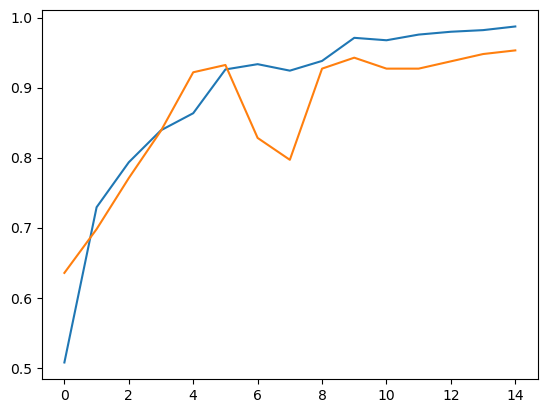

In [46]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


In [48]:
model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.9529 - loss: 0.1291


[0.13820171356201172, 0.9612069129943848]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step


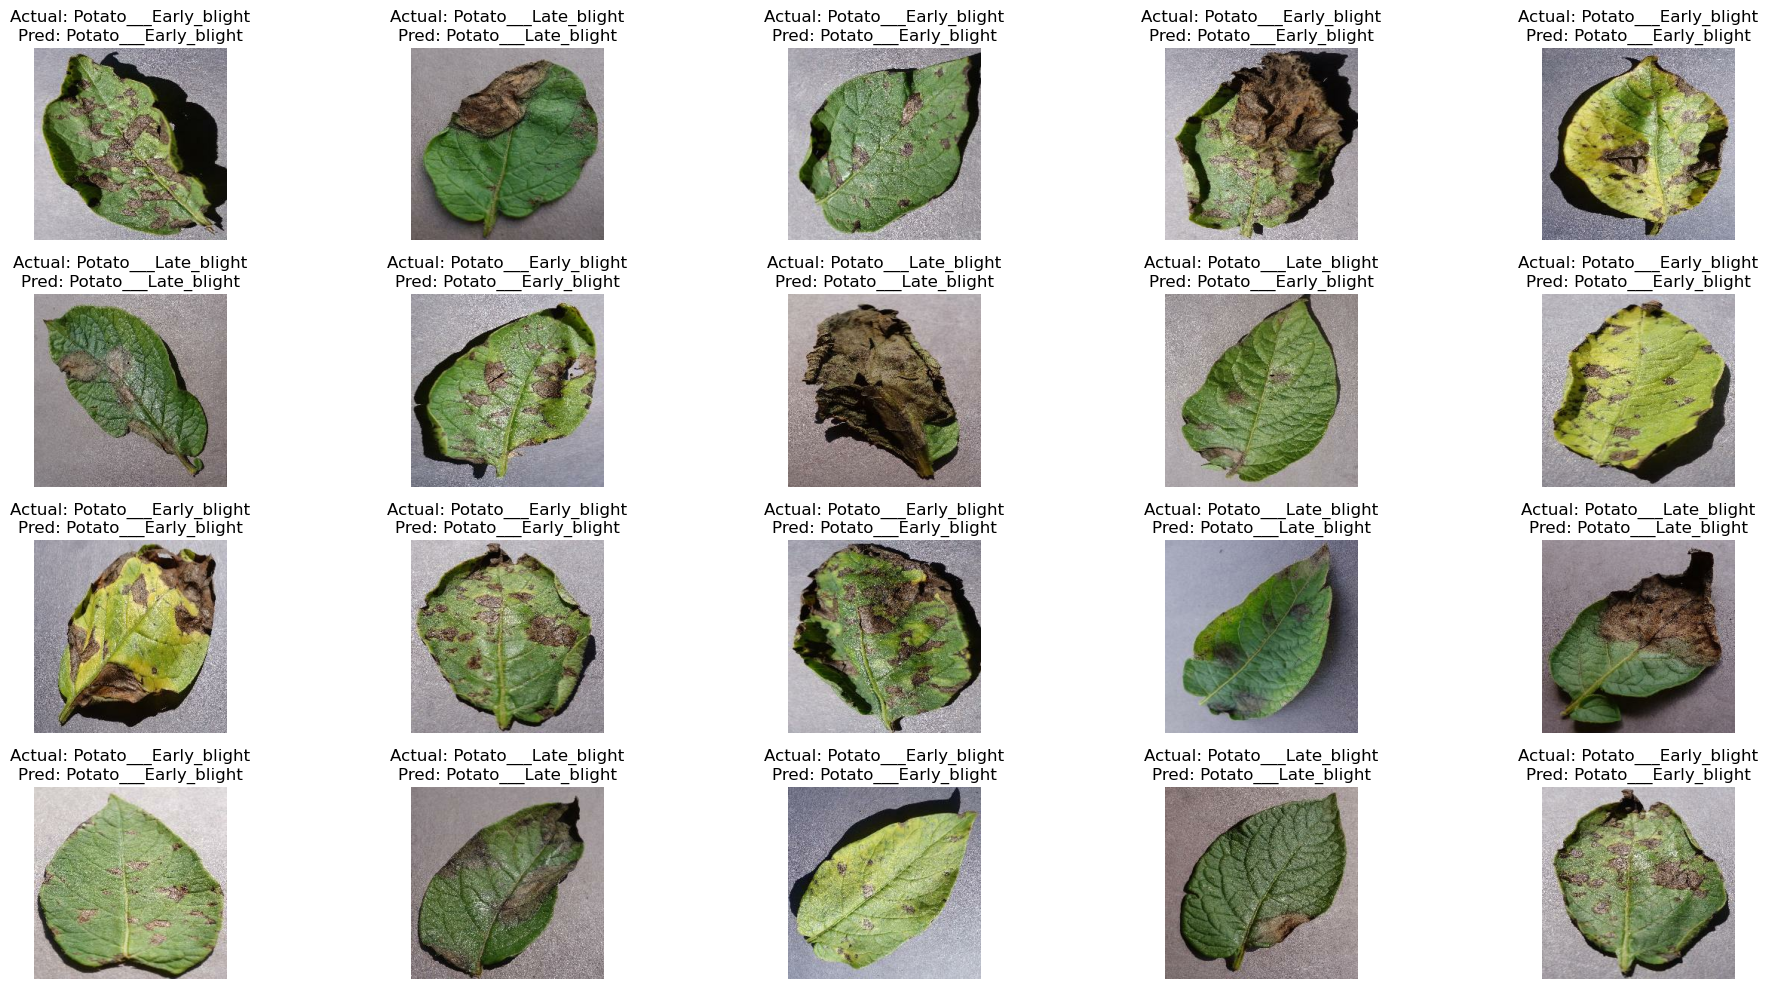

In [50]:
plt.figure(figsize=(20,10))
#here image is batch of 32 so predict is also bath of 32
for images, labels in test_ds.take(1):

    batch_predict = model.predict(images)

    for i in range(20):
        plt.subplot(4,5,i+1)

        first_image = images[i].numpy().astype("uint8")
        first_label = labels[i].numpy()

        predicted_label = np.argmax(batch_predict[i])

        plt.imshow(first_image)
        plt.title(
            f"Actual: {class_Names[first_label]}\nPred: {class_Names[predicted_label]}"
        )
        plt.axis("off")

plt.tight_layout()
plt.show()

In [52]:
model.save(r"C:\Users\gaura\Downloads\archive\PlantVillage\plant_disease_model.keras")